Running Original Solver Method...
Running Vectorized Contour Method...


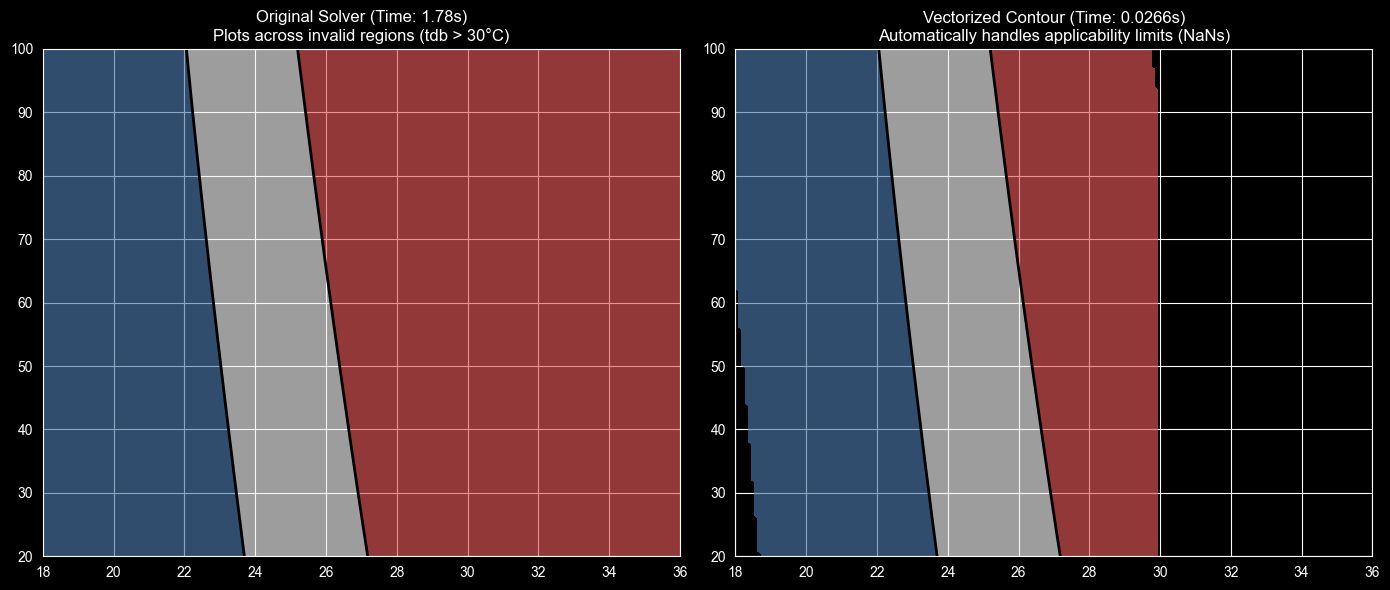

✅ Output Verification:
Original Solver returned: 2 Line2D objects.
Vectorized Contour returned: 2 Line2D objects.
Both methods support post-rendering customization (e.g., ax.lines[0].set_linewidth()).


In [2]:
# Demo_Comparison.ipynb
import time

import matplotlib.pyplot as plt
from range_scene import RangeScene

from pythermalcomfort.models import pmv_ppd_iso

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# Method 1: Original Solver Approach
# ==========================================
print("Running Original Solver Method...")
start_time = time.time()
scene_solver = (
    RangeScene(model_func=pmv_ppd_iso)
    .x(tdb=(18.0, 36.0))
    .y(rh=(20.0, 100.0))
    .parameters(
        vr=0.10,
        met=1.2,
        clo=0.5,
        wme=0.0,
        # The solver currently does not automatically restrict plotting for invalid model inputs (NaNs)
    )
)
result_solver = scene_solver.plot(
    output="pmv",
    levels=[-0.5, 0.5],
    x_step=0.2,
    y_step=0.5,
    ax=axes[0],
    show_lines=True,
    line_kws={"color": "black", "linewidth": 2.0},
)
solver_time = time.time() - start_time
result_solver.ax.set_title(
    f"Original Solver (Time: {solver_time:.2f}s)\nPlots across invalid regions (tdb > 30°C)"
)

# ==========================================
# Method 2: Vectorized Contour Approach
# ==========================================
print("Running Vectorized Contour Method...")
start_time = time.time()
scene_contour = (
    RangeScene(model_func=pmv_ppd_iso)
    .x(tdb=(18.0, 36.0))
    .y(rh=(20.0, 100.0))
    .parameters(
        vr=0.10,
        met=1.2,
        clo=0.5,
        wme=0.0,
        limit_inputs=True,  # Explicitly enforcing applicability limits
    )
)
result_contour = scene_contour.plot_contour(
    output="pmv",
    levels=[-0.5, 0.5],
    grid_resolution=200,  # Running at much higher resolution
    ax=axes[1],
    show_lines=True,
    line_kws={"color": "black", "linewidth": 2.0},
)
contour_time = time.time() - start_time
result_contour.ax.set_title(
    f"Vectorized Contour (Time: {contour_time:.4f}s)\nAutomatically handles applicability limits (NaNs)"
)

plt.tight_layout()
plt.show()

# Verification of editable return objects
print("✅ Output Verification:")
print(f"Original Solver returned: {len(result_solver.lines)} Line2D objects.")
print(f"Vectorized Contour returned: {len(result_contour.lines)} Line2D objects.")
print(
    "Both methods support post-rendering customization (e.g., ax.lines[0].set_linewidth())."
)